In [26]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import display

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


In [27]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

project_root_path = ''

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # IMPORTANT: Update this path to match your Google Drive folder structure
    project_root_path = '/content/drive/MyDrive/AIML assignment'
else:
    # Path for local execution (assumes notebook is in 'notebooks/2_modeling')
    project_root_path = '../..'

# Define the results path based on the root
results_path = os.path.join(project_root_path, 'results')

# Verify the path exists
print(f"Project Root Path set to: {project_root_path}")
print(f"Results Path set to: {results_path}")

if not os.path.isdir(results_path):
    print(f"\n ERROR: The results directory was not found at '{results_path}'")
    print("Please ensure the 'project_root_path' is correct and the folder exists.")
else:
    print("\n✓ Successfully found results directory.")
    print(f"Contents: {os.listdir(results_path)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project Root Path set to: /content/drive/MyDrive/AIML assignment
Results Path set to: /content/drive/MyDrive/AIML assignment/results

✓ Successfully found results directory.
Contents: ['outputs', 'EDA_Visualization', 'preprocessed_reviews.csv', 'logistic_regression_IT24100209', 'lightgbm_IT24100109', 'naive_bayes_IT24100095', 'neural_network_IT24100156', 'random_forest_IT24100068', 'svm_IT24100163', 'vectorizer.pkl', 'logistic_regression_results', 'lightgbm_results', 'naive_bayes_results', 'neural_network_results', 'model_comparison_summary.csv']


In [28]:
models = {
    'Logistic Regression': 'logistic_regression_results',
    'Naive Bayes': 'naive_bayes_results',
    'Random Forest': 'random_forest_IT24100068',
    'SVM': 'svm_IT24100163',
    'LightGBM': 'lightgbm_results',
    'Neural Network': 'neural_network_results'
}

print("\n--- Model folders to search for: ---")
for name, folder in models.items():
    print(f"  • {name}: {folder}")



--- Model folders to search for: ---
  • Logistic Regression: logistic_regression_results
  • Naive Bayes: naive_bayes_results
  • Random Forest: random_forest_IT24100068
  • SVM: svm_IT24100163
  • LightGBM: lightgbm_results
  • Neural Network: neural_network_results


In [29]:
def extract_accuracy(text):
    # Try to find decimal accuracy value (0.xxxx format)
    decimal_match = re.search(r'(?:Final|Tuned|Model)?\s*(?:Model)?\s*Accuracy[:\s]*(\d+\.\d+)', text, re.IGNORECASE)
    if decimal_match:
        value = float(decimal_match.group(1))
        # If value is <= 1, assume it's decimal and convert to percentage
        if value <= 1.0:
            return value * 100
        return value

    # Try to find percentage value (xx.xx% format)
    percent_match = re.search(r'(\d+\.\d+)%', text)
    if percent_match:
        return float(percent_match.group(1))

    # Try to find any decimal number
    number_match = re.search(r'(\d+\.\d+)', text)
    if number_match:
        value = float(number_match.group(1))
        if value <= 1.0:
            return value * 100
        return value

    raise ValueError(f"Could not extract accuracy from: {text}")


In [30]:
performance_data = []
print("LOADING MODEL RESULTS")

for model_name, folder in models.items():
    model_result_path = os.path.join(results_path, folder)
    print(f"\n Checking: {model_name}")
    print(f"   Path: {model_result_path}")

    if not os.path.isdir(model_result_path):
        print(f"    SKIPPED: Directory not found")
        continue

    try:
        accuracy_path = os.path.join(model_result_path, 'accuracy.txt')
        report_path = os.path.join(model_result_path, 'classification_report.csv')

        # Check if files exist
        if not os.path.exists(accuracy_path):
            print(f"    SKIPPED: accuracy.txt not found")
            continue
        if not os.path.exists(report_path):
            print(f"    SKIPPED: classification_report.csv not found")
            continue

        # Read accuracy file (can contain multiple lines and text)
        with open(accuracy_path, 'r') as f:
            accuracy_text = f.read().strip()
            print(f"    Raw accuracy text: {accuracy_text[:100]}...")

        # Extract accuracy using helper function
        accuracy = extract_accuracy(accuracy_text)
        print(f"    Extracted accuracy: {accuracy:.2f}%")

        # Read classification report
        report_df = pd.read_csv(report_path)

        # Find the class column (could be 'class', 'Unnamed: 0', index, etc.)
        class_col = None
        if 'class' in report_df.columns:
            class_col = 'class'
        elif 'Unnamed: 0' in report_df.columns:
            class_col = 'Unnamed: 0'
        elif report_df.index.name is not None:
            report_df = report_df.reset_index()
            class_col = report_df.columns[0]
        else:
            class_col = report_df.columns[0]

        print(f"     Using column '{class_col}' for class names")

        # Extract weighted average metrics
        weighted_avg = report_df[report_df[class_col] == 'weighted avg']

        if weighted_avg.empty:
            print(f"     WARNING: 'weighted avg' not found, trying alternatives...")
            # Try alternative names
            weighted_avg = report_df[report_df[class_col].str.contains('weighted', case=False, na=False)]

        if weighted_avg.empty:
            print(f"    SKIPPED: Could not find weighted average in classification report")
            print(f"   Available classes: {report_df[class_col].tolist()}")
            continue

        precision = weighted_avg['precision'].iloc[0]
        recall = weighted_avg['recall'].iloc[0]
        f1_score = weighted_avg['f1-score'].iloc[0]

        performance_data.append({
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1_score
        })
        print(f"     SUCCESS: All metrics loaded")
        print(f"      Accuracy: {accuracy:.2f}%, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1_score:.4f}")

    except FileNotFoundError as e:
        print(f" SKIPPED: File not found - {e}")
    except KeyError as e:
        print(f" SKIPPED: Column not found in report - {e}")
    except ValueError as e:
        print(f" SKIPPED: Could not parse values - {e}")
    except Exception as e:
        print(f" SKIPPED: Unexpected error - {type(e).__name__}: {e}")


LOADING MODEL RESULTS

 Checking: Logistic Regression
   Path: /content/drive/MyDrive/AIML assignment/results/logistic_regression_results
    Raw accuracy text: Final Model Accuracy: 0.8900 (89.00%)...
    Extracted accuracy: 89.00%
     Using column 'Unnamed: 0' for class names
     SUCCESS: All metrics loaded
      Accuracy: 89.00%, Precision: 0.8901, Recall: 0.8900, F1: 0.8900

 Checking: Naive Bayes
   Path: /content/drive/MyDrive/AIML assignment/results/naive_bayes_results
    Raw accuracy text: Baseline Model Accuracy: 0.8622
Final Tuned Model Accuracy: 0.8874...
    Extracted accuracy: 86.22%
     Using column 'Unnamed: 0' for class names
     SUCCESS: All metrics loaded
      Accuracy: 86.22%, Precision: 0.8874, Recall: 0.8874, F1: 0.8874

 Checking: Random Forest
   Path: /content/drive/MyDrive/AIML assignment/results/random_forest_IT24100068
    Raw accuracy text: Model Accuracy: 0.8595 (85.95%)...
    Extracted accuracy: 85.95%
     Using column 'Unnamed: 0' for class names


In [31]:
print(f"LOADING COMPLETE: {len(performance_data)} models loaded successfully")

results_df = pd.DataFrame(performance_data)

print("MODEL PERFORMANCE COMPARISON")


if not results_df.empty:
    # Sort by Accuracy (descending) and display
    sorted_results = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
    sorted_results.index = sorted_results.index + 1  # Start index from 1

    display(sorted_results.round(4))

    # Print summary
    best_model = sorted_results.iloc[0]
    print(f"\n BEST PERFORMING MODEL: {best_model['Model']}")
    print(f"   Accuracy: {best_model['Accuracy']:.2f}%")
    print(f"   F1-Score: {best_model['F1-Score']:.4f}")

else:
    print(" No model results were loaded successfully.")


LOADING COMPLETE: 6 models loaded successfully
MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
1,SVM,89.01,0.8903,0.8901,0.8901
2,Logistic Regression,89.00,0.8901,0.8900,0.8900
3,Neural Network,88.92,0.8892,0.8892,0.8892
4,LightGBM,86.27,0.8795,0.8795,0.8795
5,Naive Bayes,86.22,0.8874,0.8874,0.8874
6,Random Forest,85.95,0.8595,0.8595,0.8595



 BEST PERFORMING MODEL: SVM
   Accuracy: 89.01%
   F1-Score: 0.8901


VISUALIZATIONS


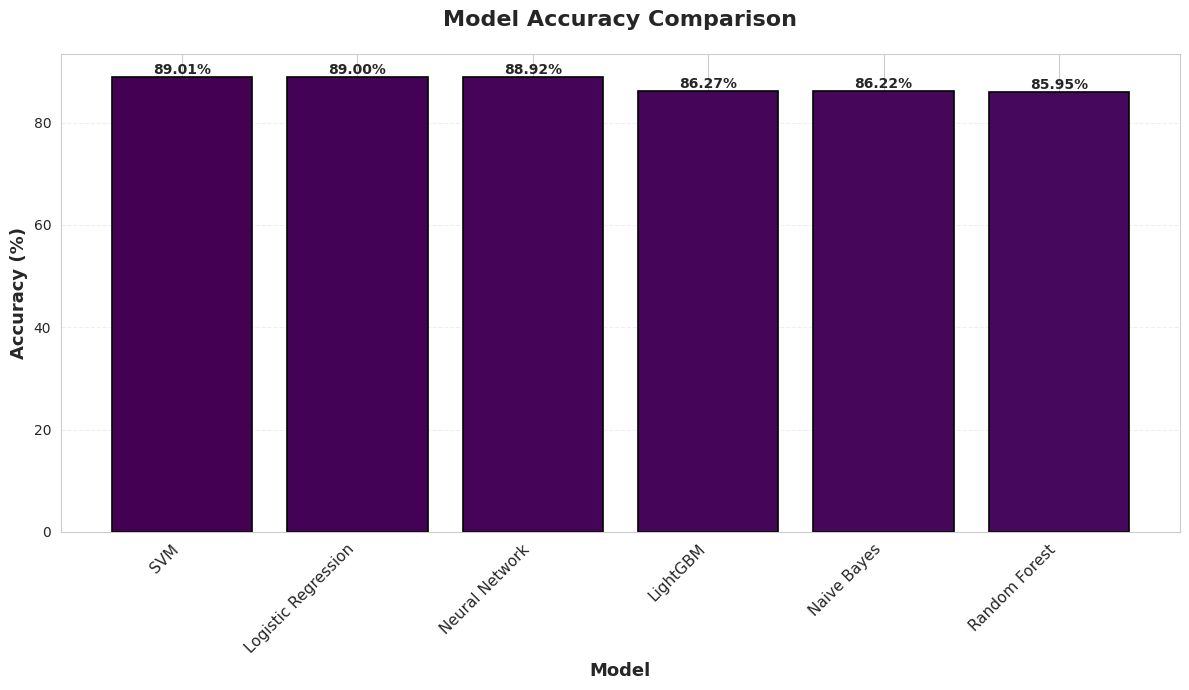

In [32]:
def plot_comparison(metric, title, ylabel=None, percentage=False):
    if results_df.empty:
        print(f"  Cannot generate plot for '{metric}' - no data available")
        return

    # Sort data by metric for better visualization
    plot_data = results_df.sort_values(by=metric, ascending=False)

    plt.figure(figsize=(12, 7))

    # Create bar plot with custom colors
    colors = plt.cm.viridis(range(len(plot_data)))
    bars = plt.bar(range(len(plot_data)), plot_data[metric], color=colors, edgecolor='black', linewidth=1.2)

    # Customize plot
    plt.title(title, fontsize=16, weight='bold', pad=20)
    plt.xlabel('Model', fontsize=13, weight='bold')
    plt.ylabel(ylabel if ylabel else metric, fontsize=13, weight='bold')
    plt.xticks(range(len(plot_data)), plot_data['Model'], rotation=45, ha='right', fontsize=11)

    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, plot_data[metric])):
        height = bar.get_height()
        if percentage:
            label = f'{value:.2f}%'
        else:
            label = f'{value:.4f}'
        plt.text(bar.get_x() + bar.get_width()/2., height,
                label,
                ha='center', va='bottom', fontsize=10, weight='bold')

    # Add grid for better readability
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

# Plot accuracy comparison
if not results_df.empty:
    print("VISUALIZATIONS")

    plot_comparison('Accuracy',
                    'Model Accuracy Comparison',
                    ylabel='Accuracy (%)',
                    percentage=True)


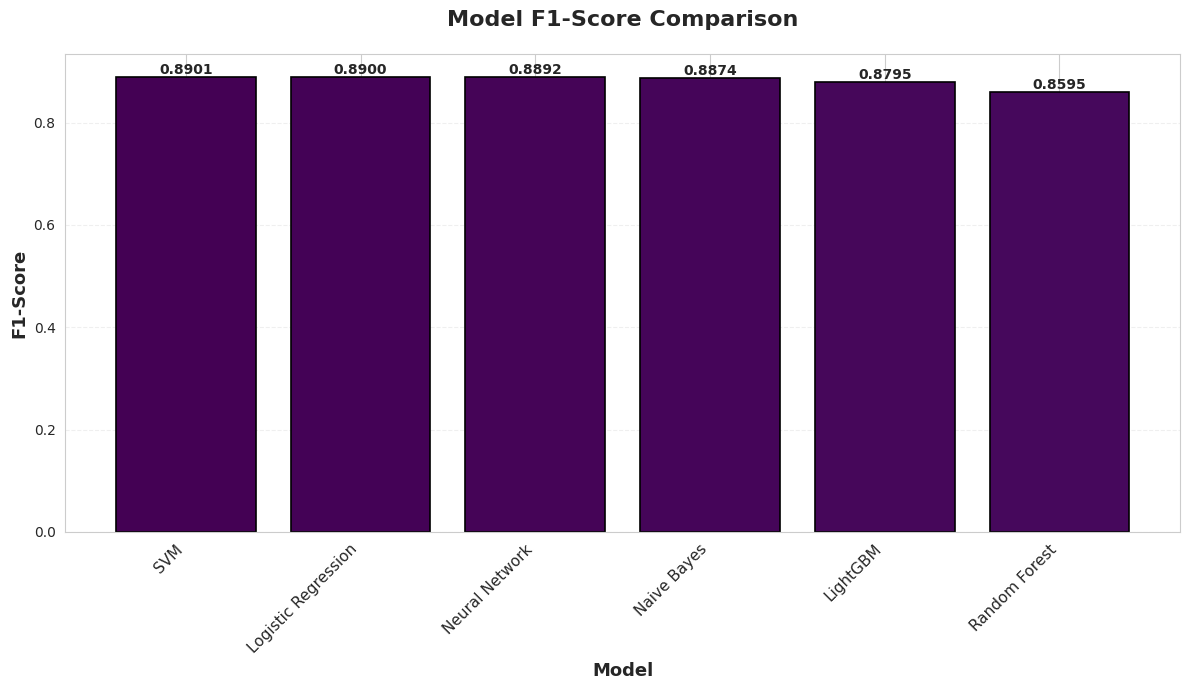

In [33]:
if not results_df.empty:
    plot_comparison('F1-Score',
                    'Model F1-Score Comparison',
                    ylabel='F1-Score')



 Generating combined metrics comparison...


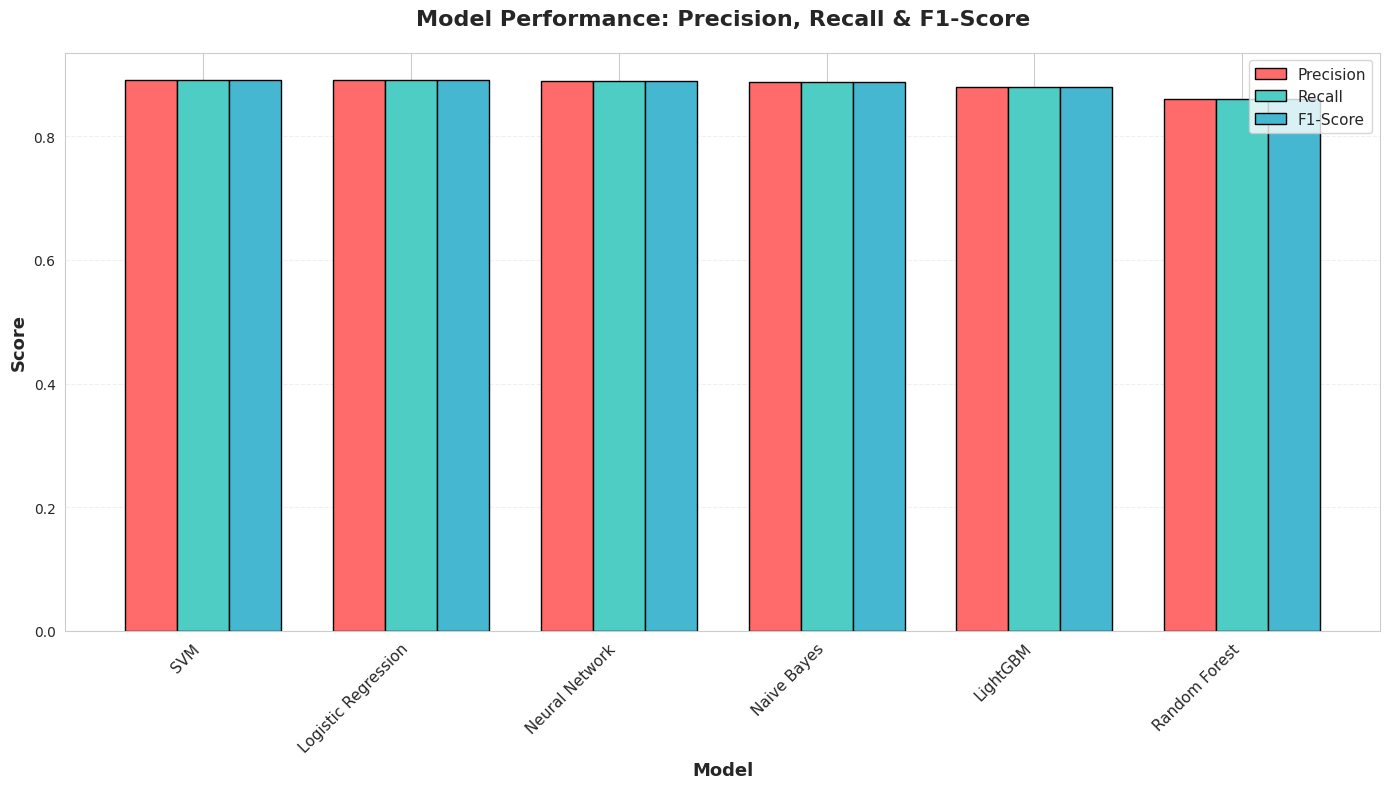

In [34]:
if not results_df.empty:
    print("\n Generating combined metrics comparison...")

    plt.figure(figsize=(14, 8))

    # Prepare data for grouped bar chart
    metrics = ['Precision', 'Recall', 'F1-Score']
    x = range(len(results_df))
    width = 0.25

    # Sort by F1-Score for consistency
    plot_data = results_df.sort_values(by='F1-Score', ascending=False)

    # Create bars for each metric
    bars1 = plt.bar([i - width for i in x], plot_data['Precision'], width,
                     label='Precision', color='#FF6B6B', edgecolor='black', linewidth=1)
    bars2 = plt.bar(x, plot_data['Recall'], width,
                     label='Recall', color='#4ECDC4', edgecolor='black', linewidth=1)
    bars3 = plt.bar([i + width for i in x], plot_data['F1-Score'], width,
                     label='F1-Score', color='#45B7D1', edgecolor='black', linewidth=1)

    # Customize plot
    plt.xlabel('Model', fontsize=13, weight='bold')
    plt.ylabel('Score', fontsize=13, weight='bold')
    plt.title('Model Performance: Precision, Recall & F1-Score', fontsize=16, weight='bold', pad=20)
    plt.xticks(x, plot_data['Model'], rotation=45, ha='right', fontsize=11)
    plt.legend(fontsize=11, loc='best')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()


In [35]:
if not results_df.empty:
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60 + "\n")

    summary_stats = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].describe()
    display(summary_stats.round(4))

    print("\n✓ Analysis Complete!")




SUMMARY STATISTICS



,Accuracy,Precision,Recall,F1-Score
count,6.0000,6.0000,6.0000,6.0000
mean,87.5617,0.8827,0.8826,0.8826
std,1.5542,0.0120,0.0120,0.0120
min,85.9500,0.8595,0.8595,0.8595
25%,86.2325,0.8815,0.8815,0.8815
50%,87.5950,0.8883,0.8883,0.8883
75%,88.9800,0.8899,0.8898,0.8898
max,89.0100,0.8903,0.8901,0.8901



✓ Analysis Complete!


In [36]:
if not results_df.empty:
    try:
        output_path = os.path.join(results_path, 'model_comparison_summary.csv')
        results_df.to_csv(output_path, index=False)
        print(f"\n Results exported to: {output_path}")
    except Exception as e:
        print(f"\n  Could not export results: {e}")



 Results exported to: /content/drive/MyDrive/AIML assignment/results/model_comparison_summary.csv
